# 03 · Ознаки з фото: CLIP-ембедінги, zero-shot, якість, дублікати

**План:**
1. Один прохід по всіх ~38k фото: CLIP ViT-L/14 (`datacomp_xl_s13b_b90k`) ембедінги +
   прості метрики якості (розмір, яскравість, контраст, різкість, насиченість). Кеш у `data/processed/`.
2. Zero-shot ознаки з текстових промптів: кіт/собака, вік, порода, шерсть, колір,
   кількість тварин, здоров'я, обстановка, людина в кадрі, якість фото.
3. Агрегація по тварині: перше фото (його бачать першим), середнє, максимум.
4. Майже-дублікати фото + kNN-target (OOF) на ембедінгах — як для тексту.
5. Схожість опису та фото у спільному просторі CLIP.

Результат: `data/processed/img_feats_{train,test}.parquet`, `clip_pet_{first,mean}.npy`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

from src.config import *
from src.utils import seed_everything, qwk, OptimizedRounder
from src.models import run_lgb_cv

seed_everything(SEED)
pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")

In [2]:
import torch
from src.images import (load_clip, extract_image_features, zero_shot_features,
                        aggregate_per_pet, pet_embeddings, encode_texts, CLIP_MODEL, CLIP_PRETRAINED)
from src.features import duplicate_groups, group_size, knn_target_features

img_index = pd.read_parquet(PROCESSED_DIR / "image_index.parquet")
train = pd.read_parquet(PROCESSED_DIR / "train_meta.parquet")
test = pd.read_parquet(PROCESSED_DIR / "test_meta.parquet")
y, folds, n_tr = train[TARGET_COL].values, train["fold"].values, len(train)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device, len(img_index), "images")

cuda 37920 images


In [3]:
def spearman_table(df: pd.DataFrame, y) -> pd.Series:
    """Spearman correlation of every column with the target (NaN filled with -1)."""
    return df.apply(lambda c: spearmanr(c.fillna(-1), y)[0]).sort_values()

## 1. CLIP-ембедінги та якість фото (один прохід, з кешем)

Перший запуск — ~10–15 хв на RTX 4080 Laptop (упирається в читання JPEG); далі — з кешу.

In [4]:
EMB_PATH = PROCESSED_DIR / "clip_img_emb.npy"
QUAL_PATH = PROCESSED_DIR / "img_quality.parquet"

model, preprocess, tokenizer = load_clip(CLIP_MODEL, CLIP_PRETRAINED, device)
if EMB_PATH.exists() and QUAL_PATH.exists():
    img_emb, img_qual = np.load(EMB_PATH), pd.read_parquet(QUAL_PATH)
else:
    img_emb, img_qual = extract_image_features(img_index["path"].tolist(), model, preprocess, device,
                                               batch_size=128, num_workers=6)
    np.save(EMB_PATH, img_emb)
    img_qual.to_parquet(QUAL_PATH, index=False)
assert len(img_emb) == len(img_index)
img_emb.shape, img_qual.describe().T.round(1)

((37920, 768),
                 count    mean     std   min     25%     50%     75%      max
 img_w         37920.0   400.6   125.0  50.0   300.0   400.0   400.0   1792.0
 img_h         37920.0   389.0    94.2  35.0   300.0   400.0   480.0   3184.0
 img_aspect    37920.0     1.1     0.4   0.2     0.8     1.1     1.3      4.9
 img_kb        37920.0    27.0    16.7   0.9    16.6    22.5    32.5   1163.1
 brightness    37920.0   120.3    28.0   5.9   103.0   120.5   137.3    252.8
 contrast      37920.0    56.7    13.4   5.2    47.6    56.5    65.5    115.8
 sharpness     37920.0  1984.3  1336.1  33.8  1053.7  1599.7  2538.3  10380.6
 colorfulness  37920.0    32.8    17.7   0.0    20.6    29.1    40.5    151.1)

## 2. Zero-shot ознаки

Для кожної групи промптів — softmax по класах (усереднення кількох промптів на клас).

In [5]:
zs = zero_shot_features(img_emb, model, tokenizer, device)
pet_img = aggregate_per_pet(img_index, pd.concat([img_qual, zs], axis=1), aggs=("first", "mean", "max"))
pet_img.shape

(8330, 109)

In [6]:
# Sanity check: CLIP "cat" vs cat/dog keywords in the description
txt = pd.read_parquet(PROCESSED_DIR / "text_feats_train.parquet")
chk = train[[ID_COL]].merge(pet_img[[ID_COL, "zs_type_cat_mean"]], on=ID_COL).merge(txt[[ID_COL, "type_text"]], on=ID_COL)
pd.crosstab(chk["type_text"], chk["zs_type_cat_mean"] > 0.5, margins=True)

zs_type_cat_mean,False,True,All
type_text,,,
-1,11,2025,2036
0,1190,744,1934
1,2437,24,2461
All,3638,2793,6431


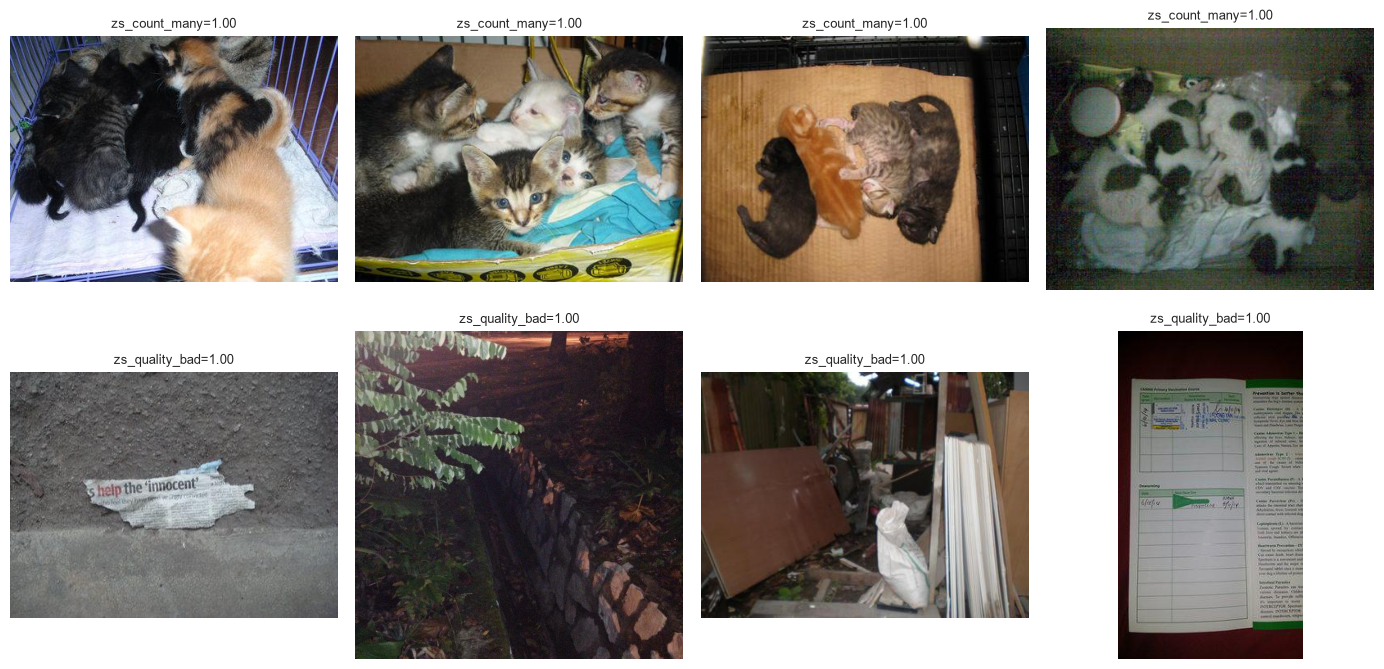

In [7]:
# A few photos with the most confident "many animals" / "screenshot" predictions
from PIL import Image
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row, col in zip(axes, ["zs_count_many", "zs_quality_bad"]):
    for ax, i in zip(row, np.argsort(-zs[col].values)[:4]):
        ax.imshow(Image.open(img_index["path"].iloc[i])); ax.axis("off")
        ax.set_title(f"{col}={zs[col].iloc[i]:.2f}", fontsize=9)
plt.tight_layout();

## 3. Ембедінги на рівні тварини, дублікати фото, kNN-target (OOF)

In [8]:
pet_ids, emb_first, emb_mean = pet_embeddings(img_index, img_emb)
pos = pd.Series(np.arange(len(pet_ids)), index=pet_ids)
tr_pos, te_pos = pos[train[ID_COL]].to_numpy(), pos[test[ID_COL]].to_numpy()

E_tr, E_te = emb_mean[tr_pos], emb_mean[te_pos]
np.save(PROCESSED_DIR / "clip_pet_mean_train.npy", E_tr); np.save(PROCESSED_DIR / "clip_pet_mean_test.npy", E_te)
np.save(PROCESSED_DIR / "clip_pet_first_train.npy", emb_first[tr_pos]); np.save(PROCESSED_DIR / "clip_pet_first_test.npy", emb_first[te_pos])

In [9]:
# How similar are nearest photos across pets? Pick a duplicate threshold from this
E_all = np.vstack([E_tr, E_te])
sims = []
for thr in [0.98, 0.95, 0.92, 0.9]:
    g = duplicate_groups(E_all, threshold=thr)
    s = group_size(g)
    gtr = pd.DataFrame({"g": g[:n_tr], "y": y, "s": s[:n_tr]}).query("s > 1")
    sims.append({"thr": thr, "train_in_groups": len(gtr), "max_size": s.max(),
                 "within_std": gtr.groupby("g")["y"].std().mean(),
                 "test_with_train_dup": np.isin(g[n_tr:], g[:n_tr]).sum()})
pd.DataFrame(sims).round(3)

,thr,train_in_groups,max_size,within_std,test_with_train_dup
0,0.98,96,4,0.193,21
1,0.95,530,28,0.274,162
2,0.92,2643,1673,0.394,838
3,0.90,4167,2605,0.344,1290


In [10]:
img_groups = duplicate_groups(E_all, threshold=0.95)
img_dup_size = group_size(img_groups)

knn_tr, knn_te = knn_target_features(E_tr, E_te, y, folds, prefix="img")
spearman_table(knn_tr, y)

img_nn1_sim        -0.134449
img_knn_mean_sim   -0.133069
img_nn1_y           0.371787
img_knn_y           0.491406
dtype: float64

## 4. Схожість опису та фото (CLIP text ↔ image)

Текст обрізається до 77 токенів — для «про що оголошення» цього достатньо.

In [11]:
T_tr = encode_texts(train[TEXT_COL].str.slice(0, 300).tolist(), model, tokenizer, device)
T_te = encode_texts(test[TEXT_COL].str.slice(0, 300).tolist(), model, tokenizer, device)
sim_tr = pd.DataFrame({"clip_txt_img_mean": (T_tr * E_tr).sum(1), "clip_txt_img_first": (T_tr * emb_first[tr_pos]).sum(1)})
sim_te = pd.DataFrame({"clip_txt_img_mean": (T_te * E_te).sum(1), "clip_txt_img_first": (T_te * emb_first[te_pos]).sum(1)})
np.save(PROCESSED_DIR / "clip_text_train.npy", T_tr); np.save(PROCESSED_DIR / "clip_text_test.npy", T_te)
spearman_table(sim_tr, y)

clip_txt_img_first    0.046023
clip_txt_img_mean     0.058118
dtype: float64

## 5. Збірка та швидка перевірка сигналу

LightGBM тільки на ознаках з фото (без ембедінгів як таких — їх використаємо в бейзлайні через PCA/голову).

In [12]:
img_tr = train[[ID_COL]].merge(pet_img, on=ID_COL, how="left")
img_te = test[[ID_COL]].merge(pet_img, on=ID_COL, how="left")
for df, knn, sim, sl in [(img_tr, knn_tr, sim_tr, slice(0, n_tr)), (img_te, knn_te, sim_te, slice(n_tr, None))]:
    df[knn.columns] = knn.to_numpy()
    df[sim.columns] = sim.to_numpy()
    df["img_dup_size"] = img_dup_size[sl]
feat_cols = [c for c in img_tr.columns if c != ID_COL]
print(len(feat_cols), "image features")

corr = spearman_table(img_tr[feat_cols], y)
pd.concat([corr.head(10), corr.tail(10)]).round(3)

115 image features


zs_age_baby_mean      -0.312
zs_age_baby_first     -0.308
zs_age_baby_max       -0.300
zs_breed_pure_mean    -0.283
zs_breed_pure_max     -0.275
zs_age_young_first    -0.263
zs_age_young_mean     -0.260
zs_breed_pure_first   -0.259
zs_age_young_max      -0.245
zs_count_many_first   -0.240
zs_count_one_max       0.265
zs_breed_mixed_mean    0.283
zs_age_old_max         0.318
zs_age_adult_max       0.320
zs_age_old_mean        0.338
zs_age_adult_mean      0.346
zs_age_adult_first     0.349
zs_age_old_first       0.354
img_nn1_y              0.372
img_knn_y              0.491
dtype: float64

fold 0: best_iter= 172  rmse=0.9246


fold 1: best_iter= 271  rmse=0.9148


fold 2: best_iter= 207  rmse=0.9226


fold 3: best_iter= 259  rmse=0.9128


fold 4: best_iter= 210  rmse=0.9047


OOF QWK: 0.5581   thresholds: [2.086 2.499 3.035]


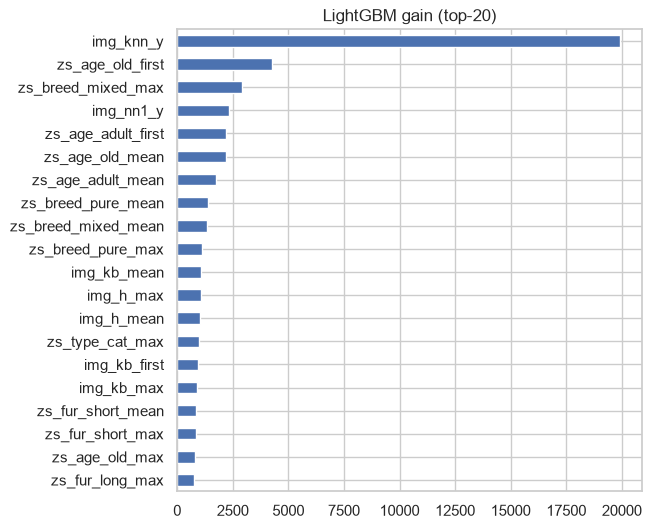

In [13]:
X_tr = pd.concat([train[["n_photos"]].reset_index(drop=True), img_tr[feat_cols]], axis=1)
X_te = pd.concat([test[["n_photos"]].reset_index(drop=True), img_te[feat_cols]], axis=1)
res = run_lgb_cv(X_tr, X_te, y, folds)
res["importance"].head(20).plot.barh(figsize=(6, 6), title="LightGBM gain (top-20)").invert_yaxis();

In [14]:
img_tr.to_parquet(PROCESSED_DIR / "img_feats_train.parquet", index=False)
img_te.to_parquet(PROCESSED_DIR / "img_feats_test.parquet", index=False)
print(img_tr.shape, img_te.shape)

(6431, 116) (1891, 116)


## 6. Другий енкодер: SigLIP2 (ViT-SO400M-16, 384 px)

Фото — найсильніша модальність, тому додаємо другий, незалежно навчений енкодер.
SigLIP2 (Google, 2025) навчений на WebLI з сигмоїдним лоссом; його текстовий енкодер
багатомовний (корисно для малайських / китайських описів), а вхід 384 px
дає більше деталей (шерсть, вік). Той самий пайплайн: ембедінги → zero-shot →
агрегація по тварині → OOF kNN-target → схожість текст↔фото. Усі колонки з префіксом `siglip_`.

Перший запуск — ~12 хв (кеш `siglip_img_emb.npy`).

In [15]:
from src.images import encoder_feature_pipeline
from src.models import ridge_oof

sig_tr, sig_te = encoder_feature_pipeline(
    "siglip", "ViT-SO400M-16-SigLIP2-384", "webli", img_index, train, test, PROCESSED_DIR, device,
)
sig_cols = [c for c in sig_tr.columns if c != ID_COL]
print(len(sig_cols), "SigLIP features")

# Same zero-shot feature, two encoders: which one correlates better with the target?
cmp = pd.DataFrame({
    "CLIP": spearman_table(img_tr[[c for c in feat_cols if c.startswith("zs_")]], y),
    "SigLIP2": spearman_table(sig_tr[sig_cols].rename(columns=lambda c: c.removeprefix("siglip_")), y),
}).dropna()
cmp.reindex(cmp["CLIP"].abs().sort_values(ascending=False).index).head(15).round(3)

images:   0%|          | 0/593 [00:11<?, ?it/s]

C:\Users\pbori\Documents\Courses\Neoversity\DeepL\neoversity-dl-cv-final\src\images.py:252: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  zs = zero_shot_features(img_emb, model, tokenizer, device, logit_scale=float(model.logit_scale.exp()))


90 SigLIP features


,CLIP,SigLIP2
zs_age_old_first,0.354,0.266
zs_age_adult_first,0.349,0.323
zs_age_adult_mean,0.346,0.325
zs_age_old_mean,0.338,0.253
zs_age_adult_max,0.320,0.309
zs_age_old_max,0.318,0.238
zs_age_baby_mean,-0.312,-0.291
zs_age_baby_first,-0.308,-0.286
zs_age_baby_max,-0.300,-0.280
zs_breed_mixed_mean,0.283,0.038


In [16]:
# Level-1 Ridge on raw embeddings (saved for stacking in 04/06)
def load_pair_npy(name):
    return np.load(PROCESSED_DIR / f"{name}_train.npy"), np.load(PROCESSED_DIR / f"{name}_test.npy")

(m_tr, m_te), (f_tr, f_te) = load_pair_npy("siglip_pet_mean"), load_pair_npy("siglip_pet_first")
ridge_specs = {
    "ridge_siglip_img": (np.hstack([m_tr, f_tr]), np.hstack([m_te, f_te])),
    "ridge_siglip_text": load_pair_npy("siglip_text"),
}
rows = []
for name, (X_tr_r, X_te_r) in ridge_specs.items():
    best = None
    for alpha in (1.0, 3.0, 10.0):
        oof_r, te_r = ridge_oof(X_tr_r, X_te_r, y, folds, alpha=alpha)
        score = qwk(y, OptimizedRounder().fit(oof_r, y).predict(oof_r))
        rows.append({"model": name, "alpha": alpha, "OOF QWK": score})
        if best is None or score > best[0]:
            best = (score, oof_r, te_r)
    np.save(PROCESSED_DIR / f"oof_{name}.npy", best[1]); np.save(PROCESSED_DIR / f"test_{name}.npy", best[2])

oof_clip = np.load(PROCESSED_DIR / "oof_ridge_clip_img.npy")
rows.append({"model": "ridge_clip_img (для порівняння)", "alpha": 3.3,
             "OOF QWK": qwk(y, OptimizedRounder().fit(oof_clip, y).predict(oof_clip))})
pd.DataFrame(rows).round(4)

,model,alpha,OOF QWK
0,ridge_siglip_img,1.0,0.5822
1,ridge_siglip_img,3.0,0.5997
2,ridge_siglip_img,10.0,0.5917
3,ridge_siglip_text,1.0,0.2925
4,ridge_siglip_text,3.0,0.2756
5,ridge_siglip_text,10.0,0.2687
6,ridge_clip_img (для порівняння),3.3,0.5871


In [17]:
# Does SigLIP2 add to CLIP? Same LightGBM, image-only and full stack
def load_oof_pair(name):
    return np.r_[np.load(PROCESSED_DIR / f"oof_{name}.npy"), np.load(PROCESSED_DIR / f"test_{name}.npy")]

n_ph = pd.concat([train[["n_photos"]], test[["n_photos"]]], ignore_index=True)
clip_f = pd.concat([img_tr[feat_cols], img_te[feat_cols]], ignore_index=True)
sig_f = pd.concat([sig_tr[sig_cols], sig_te[sig_cols]], ignore_index=True)
text_f = pd.concat([pd.read_parquet(PROCESSED_DIR / f"text_feats_{s}.parquet") for s in ("train", "test")],
                   ignore_index=True).drop(columns=ID_COL)
ridge_old = pd.DataFrame({k: load_oof_pair(k) for k in ["ridge_clip_img", "ridge_tfidf", "ridge_clip_text"]})
ridge_sig = pd.DataFrame({k: load_oof_pair(k) for k in ["ridge_siglip_img", "ridge_siglip_text"]})

variants = {
    "фото: CLIP": [n_ph, clip_f],
    "фото: SigLIP2": [n_ph, sig_f],
    "фото: CLIP + SigLIP2": [n_ph, clip_f, sig_f],
    "усе без SigLIP2 (текст + CLIP + Ridge)": [n_ph, text_f, clip_f, ridge_old],
    "усе + SigLIP2": [n_ph, text_f, clip_f, sig_f, ridge_old, ridge_sig],
}
rows = []
for name, parts in variants.items():
    X = pd.concat(parts, axis=1)
    rows.append({"ознаки": name, "n_features": X.shape[1],
                 "OOF QWK": run_lgb_cv(X[:n_tr], X[n_tr:], y, folds, verbose=False)["qwk"]})
pd.DataFrame(rows).round(4)

,ознаки,n_features,OOF QWK
0,фото: CLIP,116,0.5581
1,фото: SigLIP2,91,0.5577
2,фото: CLIP + SigLIP2,206,0.5769
3,усе без SigLIP2 (текст + CLIP + Ridge),159,0.6064
4,усе + SigLIP2,251,0.6170


## Висновки

_(заповнити: чи є сигнал у фото, які zero-shot ознаки корисні, приріст від kNN-target по фото)_